Ejercicio 2 — Segmentación de sensores ambientales

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [5]:
df = pd.read_csv('ejercicio_2_sensores_ambientales.csv')

In [6]:
print("Primeros datos del DataFrame:")
print(df.head())

Primeros datos del DataFrame:
  Sensor  Temperatura_C  Humedad_pct  Tipo_Esperado
0     S1           10.2         20.5      Frio/Seco
1     S2            9.8         19.1      Frio/Seco
2     S3           11.1         21.0      Frio/Seco
3     S4           35.5         80.2  Calido/Humedo
4     S5           34.1         78.5  Calido/Humedo


In [11]:
X = df[['Temperatura_C', 'Humedad_pct']]

scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

print("Datos escalados:")
print(X_escalado[:5])

Datos escalados:
[[-0.7810678  -1.06126762]
 [-0.80596239 -1.11437843]
 [-0.72505497 -1.04229948]
 [ 0.7935151   1.2035287 ]
 [ 0.70638403  1.13903701]]


In [12]:
#Grafico k-distancia
vecinos = NearestNeighbors(n_neighbors=3)
vecinos_fit = vecinos.fit(X_escalado)
distancias, indices = vecinos_fit.kneighbors(X_escalado)
distancias = np.sort(distancias[:, 2])

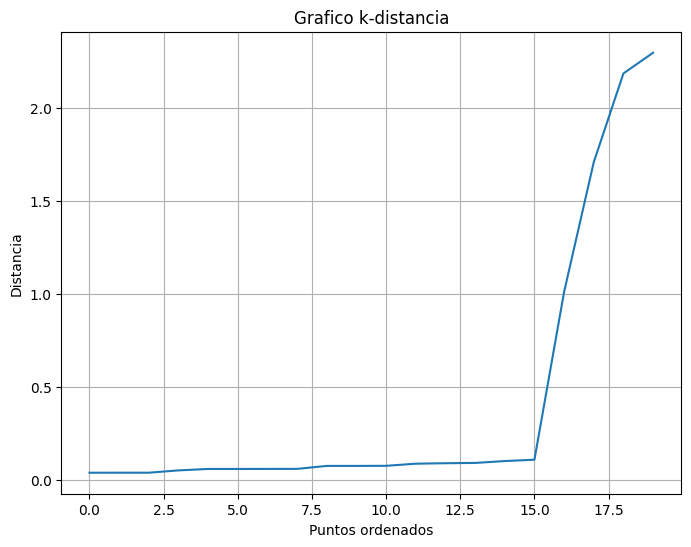

In [13]:
plt.figure(figsize=(8,6))
plt.plot(distancias)
plt.title('Grafico k-distancia')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia')
plt.grid(True)
plt.show()

In [15]:
eps_elegido = 0.7

In [20]:
#DBSCAN
modelo = DBSCAN(
    eps=eps_elegido,
    min_samples=3
)

clusters = modelo.fit_predict(X_escalado)
df['Cluster'] = clusters
print("DataFrame con clusters:")
print(df)

DataFrame con clusters:
   Sensor  Temperatura_C  Humedad_pct  Tipo_Esperado  Cluster
0      S1           10.2         20.5      Frio/Seco        0
1      S2            9.8         19.1      Frio/Seco        0
2      S3           11.1         21.0      Frio/Seco        0
3      S4           35.5         80.2  Calido/Humedo        1
4      S5           34.1         78.5  Calido/Humedo        1
5      S6           36.8         81.3  Calido/Humedo        1
6      S7           22.4         50.1       Templado        2
7      S8           21.9         49.5       Templado        2
8      S9           23.2         51.8       Templado        2
9     S10           50.0         10.0       ANOMALIA       -1
10    S11            0.0         95.0       ANOMALIA       -1
11    S12           10.5         19.8      Frio/Seco        0
12    S13           35.0         79.0  Calido/Humedo        1
13    S14           22.0         50.5       Templado        2
14    S15           36.0         82.0  Calido/

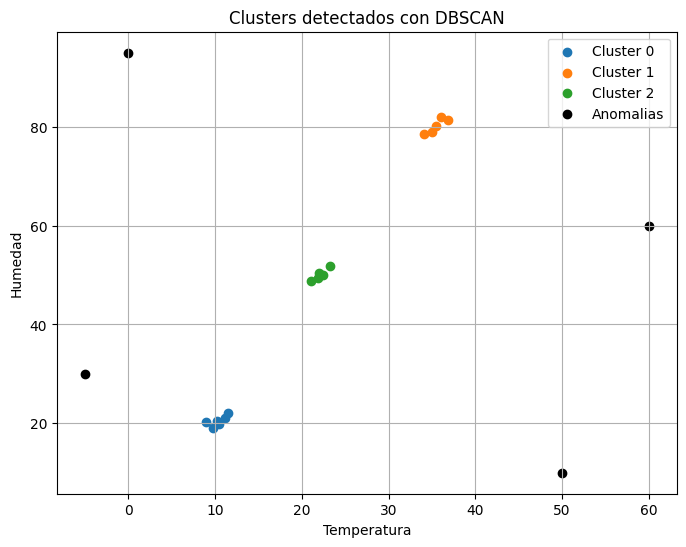

In [18]:
plt.figure(figsize=(8,6))
clusters_unicos = set(clusters)
for cluster in clusters_unicos:
    datos_cluster = df[df['Cluster'] == cluster]
    # Anomalias
    if cluster == -1:
        plt.scatter(
            datos_cluster['Temperatura_C'],
            datos_cluster['Humedad_pct'],
            color='black',
            label='Anomalias'
        )
    # Clusters normales
    else:
        plt.scatter(
            datos_cluster['Temperatura_C'],
            datos_cluster['Humedad_pct'],
            label=f'Cluster {cluster}'
        )

plt.title('Clusters detectados con DBSCAN')
plt.xlabel('Temperatura')
plt.ylabel('Humedad')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
num_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
print(f"Cantidad de clusters detectados: {num_clusters}")

Cantidad de clusters detectados: 3


Comparar: ¿K-Means hubiera detectado las anomalías? ¿Por qué sí o no?

DBSCAN puede detectar anomalias porque marca
los puntos alejados como ruido (-1).

K-Means no detecta anomalias directamente,
porque todos los puntos son obligatoriamente
asignados a un cluster.

Por eso DBSCAN es mas util cuando se busca
identificar datos atipicos o ruido.